In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/amazon_preprocessed.csv')
x = df.drop(columns=['isBestSeller', 'title'])
y = df['isBestSeller'].astype(int)

print(x.shape)
print(y.value_counts())

(1426336, 6)
isBestSeller
0    1417816
1       8520
Name: count, dtype: int64


/var/folders/kq/6lhr6m517f3dm4q7q51x27540000gn/T/ipykernel_6014/620977841.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating = df[df['stars'] > 0].groupby('price_range')['stars'].mean()


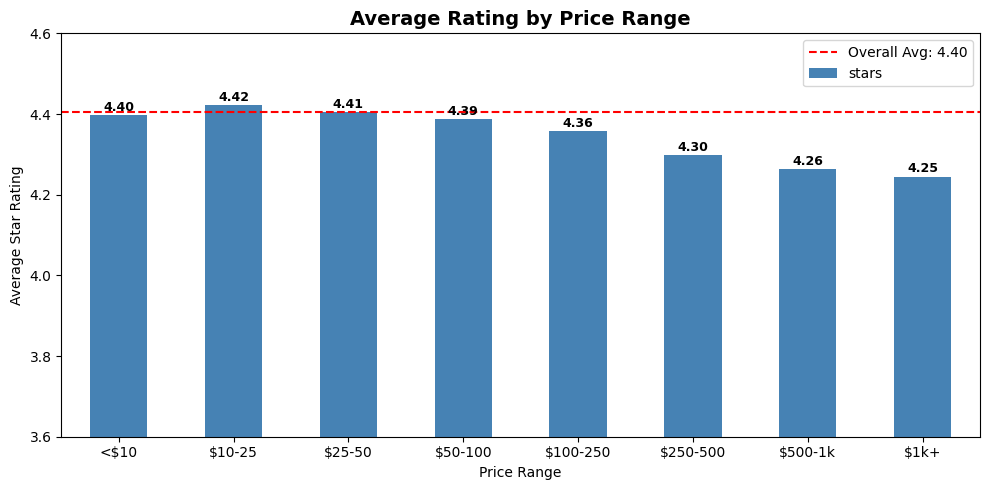

In [10]:
# Visualization 1 - Average Rating by Price Range
bins = [0, 10, 25, 50, 100, 250, 500, 1000, float('inf')]
labels = ['<$10', '$10-25', '$25-50', '$50-100', '$100-250', '$250-500', '$500-1k', '$1k+']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# filter out 0 stars (no ratings)
avg_rating = df[df['stars'] > 0].groupby('price_range')['stars'].mean()
overall_avg = df[df['stars'] > 0]['stars'].mean()

plt.figure(figsize=(10,5))
ax = avg_rating.plot(kind='bar', color='steelblue', legend=False)
plt.title('Average Rating by Price Range', fontweight='bold', fontsize=14)
plt.xlabel('Price Range')
plt.ylabel('Average Star Rating')
plt.xticks(rotation=0)
plt.axhline(y=overall_avg, color='red', linestyle='--', label=f'Overall Avg: {overall_avg:.2f}')
plt.legend()

# average rating appear ontop of each bin
for i, v in enumerate(avg_rating):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

plt.ylim(3.6, 4.6)
plt.tight_layout()
plt.show()

/var/folders/kq/6lhr6m517f3dm4q7q51x27540000gn/T/ipykernel_6014/3754587338.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_seller_rate = df[df['stars'] > 0].groupby('price_range2')['isBestSeller'].mean() * 100


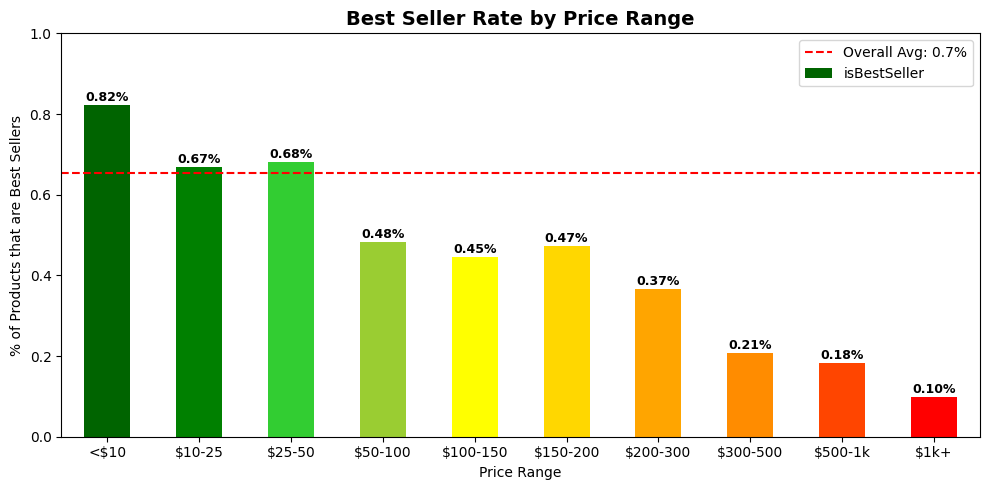

In [16]:
# Visualization 2 - Best Seller Rate by Price Range

bins2 = [0, 10, 25, 50, 100, 150, 200, 300, 500, 1000, float('inf')]
labels2 = ['<$10', '$10-25', '$25-50', '$50-100', '$100-150', '$150-200', '$200-300', '$300-500', '$500-1k', '$1k+']
df['price_range2'] = pd.cut(df['price'], bins=bins2, labels=labels2)

best_seller_rate = df[df['stars'] > 0].groupby('price_range2')['isBestSeller'].mean() * 100
overall_rate = df[df['stars'] > 0]['isBestSeller'].mean() * 100

# color scheme 
colors = ['darkgreen', 'green', 'limegreen', 'yellowgreen', 'yellow', 'gold', 'orange', 'darkorange', 'orangered', 'red']

plt.figure(figsize=(10,5))
ax = best_seller_rate.plot(kind='bar', color=colors)
plt.title('Best Seller Rate by Price Range', fontweight='bold', fontsize=14)
plt.xlabel('Price Range')
plt.ylabel('% of Products that are Best Sellers')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.axhline(y=overall_rate, color='red', linestyle='--', label=f'Overall Avg: {overall_rate:.1f}%')
plt.legend()

for i, v in enumerate(best_seller_rate):
    ax.text(i, v + 0.01, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

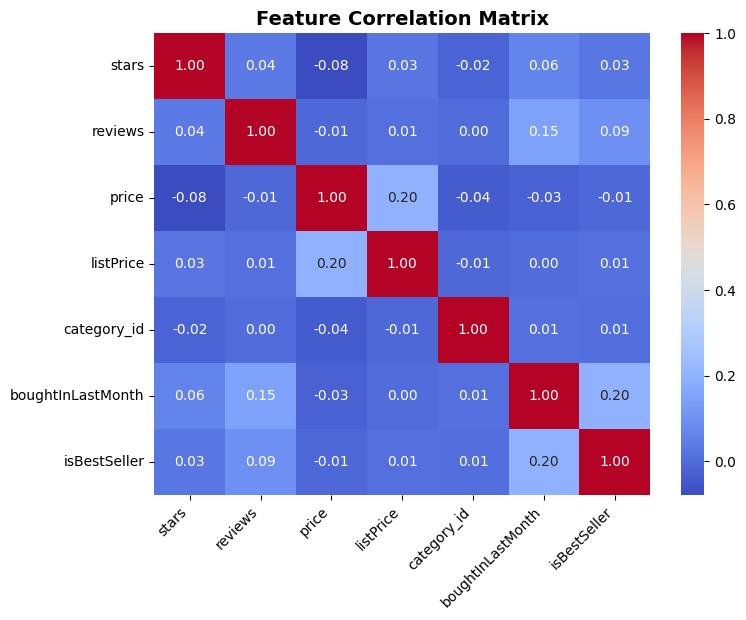

In [20]:
import seaborn as sns

# add isBestSeller for correlation matrix
corr_df = x.copy()
corr_df['isBestSeller'] = y

corr = corr_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()